In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms 
from torchvision.utils import make_grid

import math
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
image_dim = (28, 28)
lr = 2e-4
batch_size = 128 if device.type == 'cuda' else 64

In [4]:
class Generator(nn.Module):
  def __init__(self, image_dim, hidden_dims, latent_dim):
    super(Generator, self).__init__()
    dims = [latent_dim] + hidden_dims[::-1]
    self.generator = nn.Sequential()
    self.generator.append(nn.Dropout(p=0.2))
    for in_dim, out_dim in zip(dims, dims[1:]):
      self.generator.append(nn.Linear(in_dim, out_dim, bias=False))
      self.generator.append(nn.BatchNorm1d(out_dim))
      self.generator.append(nn.ReLU())

    self.generator.append(nn.Linear(dims[-1], math.prod(image_dim)))
    self.generator.append(nn.Tanh())

  def forward(self, z):
    img = self.generator(z)
    return img.view(img.shape[0], 1, *image_dim)

In [5]:
class Discriminator(nn.Module):
  def __init__(self, image_dim, hidden_dims):
    super(Discriminator, self).__init__()
    dims = [math.prod(image_dim)] + hidden_dims
    self.discriminator = nn.Sequential()
    for in_dim, out_dim in zip(dims, dims[1:]):
      self.discriminator.append(nn.Linear(in_dim, out_dim, bias=False))
      self.discriminator.append(nn.BatchNorm1d(out_dim))
      self.discriminator.append(nn.LeakyReLU(0.02))

    self.discriminator.append(nn.Linear(hidden_dims[-1], 1))
    self.discriminator.append(nn.Sigmoid())

  def forward(self, img):
    img = img.view(img.shape[0], -1)
    return self.discriminator(img)

In [6]:
latent_dim = 128  
hidden_dims = [512, 256]

generator = Generator(image_dim, hidden_dims, latent_dim).to(device)
discriminator = Discriminator(image_dim, hidden_dims).to(device)
generator, discriminator

(Generator(
   (generator): Sequential(
     (0): Dropout(p=0.2, inplace=False)
     (1): Linear(in_features=128, out_features=256, bias=False)
     (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): ReLU()
     (4): Linear(in_features=256, out_features=512, bias=False)
     (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (6): ReLU()
     (7): Linear(in_features=512, out_features=784, bias=True)
     (8): Tanh()
   )
 ),
 Discriminator(
   (discriminator): Sequential(
     (0): Linear(in_features=784, out_features=512, bias=False)
     (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): LeakyReLU(negative_slope=0.02)
     (3): Linear(in_features=512, out_features=256, bias=False)
     (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): LeakyReLU(negative_slope=0.02)
     (6): Linear(in_features=256, out_features=

In [7]:
loss = torch.nn.BCELoss()

optim_g = torch.optim.Adam(generator.parameters(), lr=lr)
optim_d = torch.optim.Adam(discriminator.parameters(), lr=lr)

In [8]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, ), (0.5, ))])

train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True, drop_last=True)

In [9]:
from tqdm import trange
epochs = 200

imgs = []
for e in range(epochs):
  g_running, d_running = 0, 0
  t = tqdm(train_dataloader)
  for i, (x, _) in enumerate(t):
    x = x.to(device)

    noise = (torch.randn((batch_size, 1)) * 0.05).abs().clamp(0.0, 0.3).to(device)
    fake = torch.zeros((batch_size, 1)).to(device) + noise
    valid = torch.ones((batch_size, 1)).to(device) - noise

    # train generator
    optim_g.zero_grad(set_to_none=True)
    z = torch.randn(batch_size, latent_dim).to(device)
    fake_x = generator(z)
    g_loss = loss(discriminator(fake_x), valid) # generator wants discriminator to think its output is valid
    g_loss.backward()
    optim_g.step()

    # train discriminator
    optim_d.zero_grad(set_to_none=True)
    fake_loss = loss(discriminator(fake_x.detach()), fake)
    real_loss = loss(discriminator(x), valid)
    d_loss = (fake_loss + real_loss) / 2
    d_loss.backward()
    optim_d.step()

    g_running += g_loss.item()
    d_running += d_loss.item()
    if i % 50 == 49:
      t.set_description(f"Epochs {e+1}/{epochs} - G loss: {g_running/49:.4f} - D loss: {d_running/49:.4f}")
      g_running, d_running = 0, 0
  if e % 25 == 0:
    grid = make_grid(fake_x.cpu().detach()[:100], nrow=10).detach()
    img = (np.transpose(grid.numpy(), (1, 2 ,0)) * 255).astype(np.uint8)
    imgs.append(img)

Epochs 200/200 - G loss: 2.7200 - D loss: 0.2584: 100%|██████████| 468/468 [00:17<00:00, 26.17it/s]


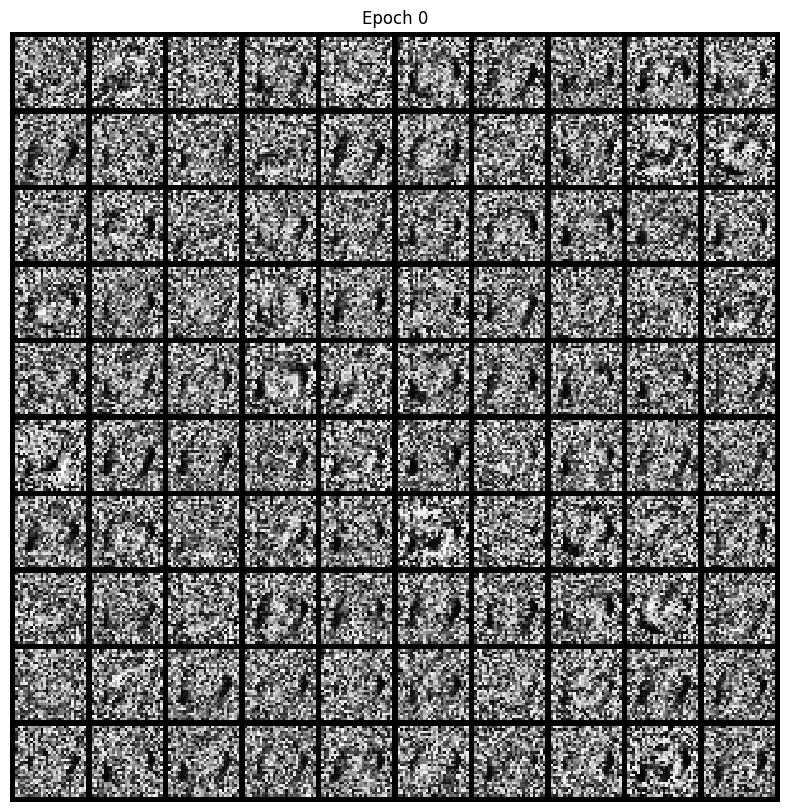

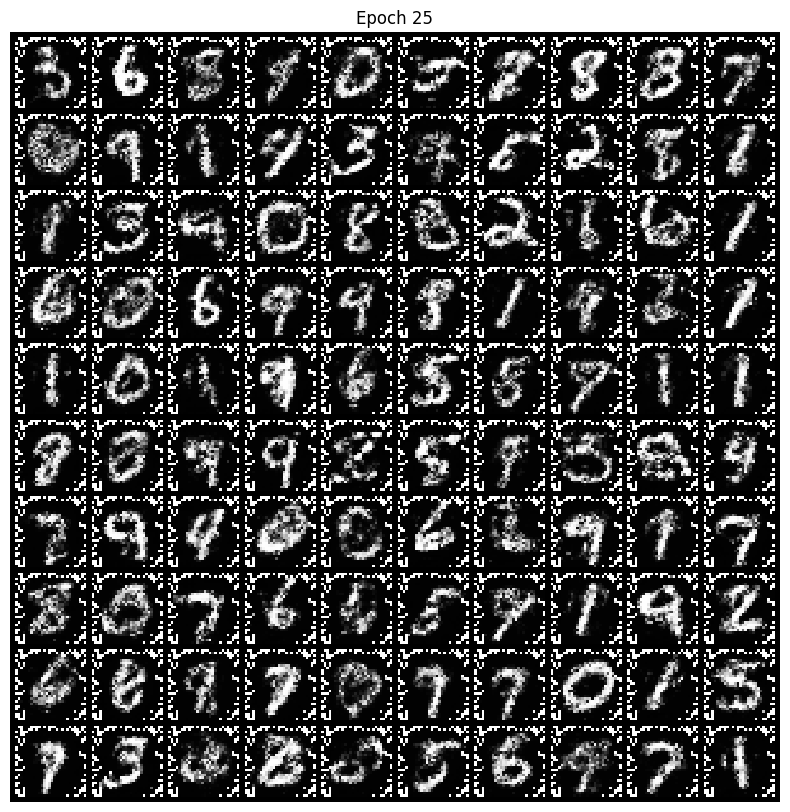

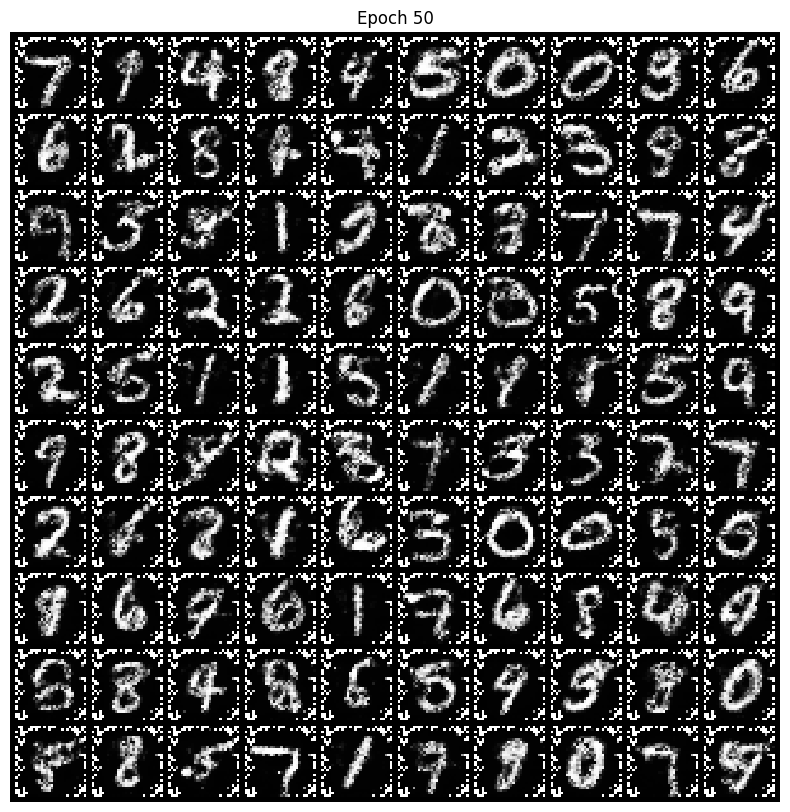

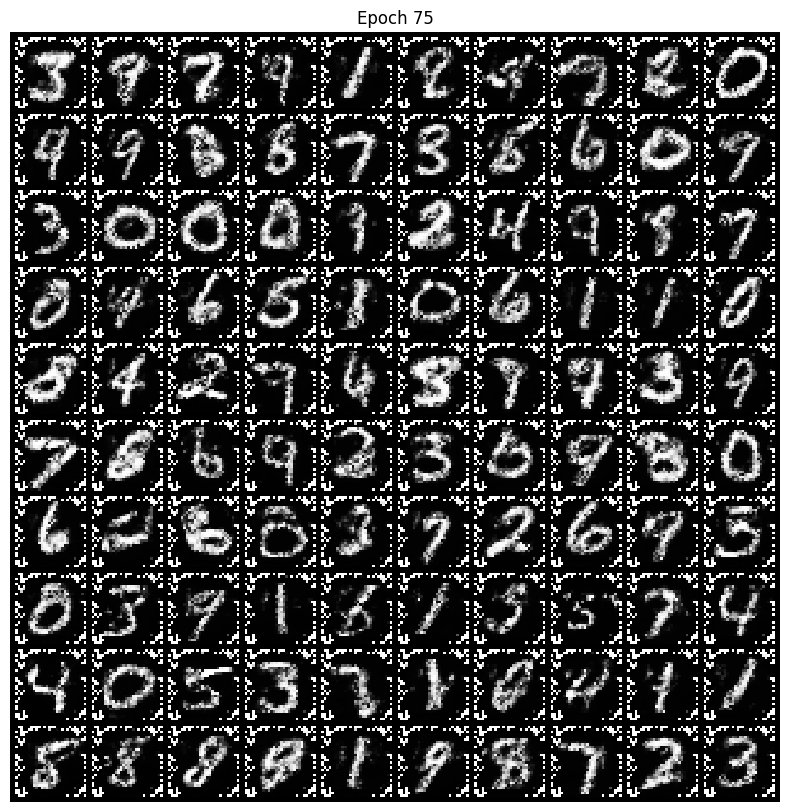

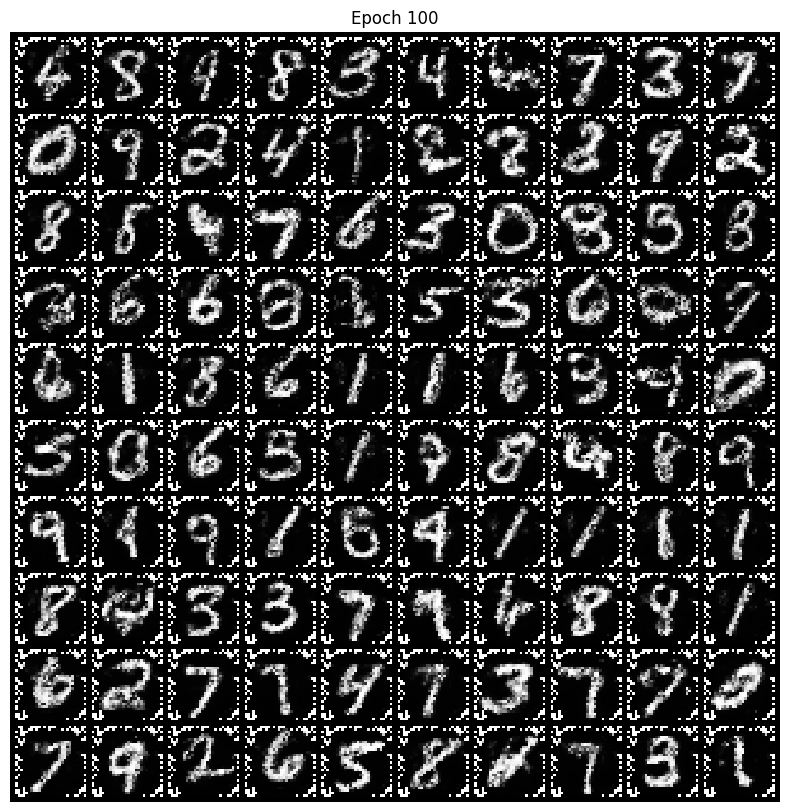

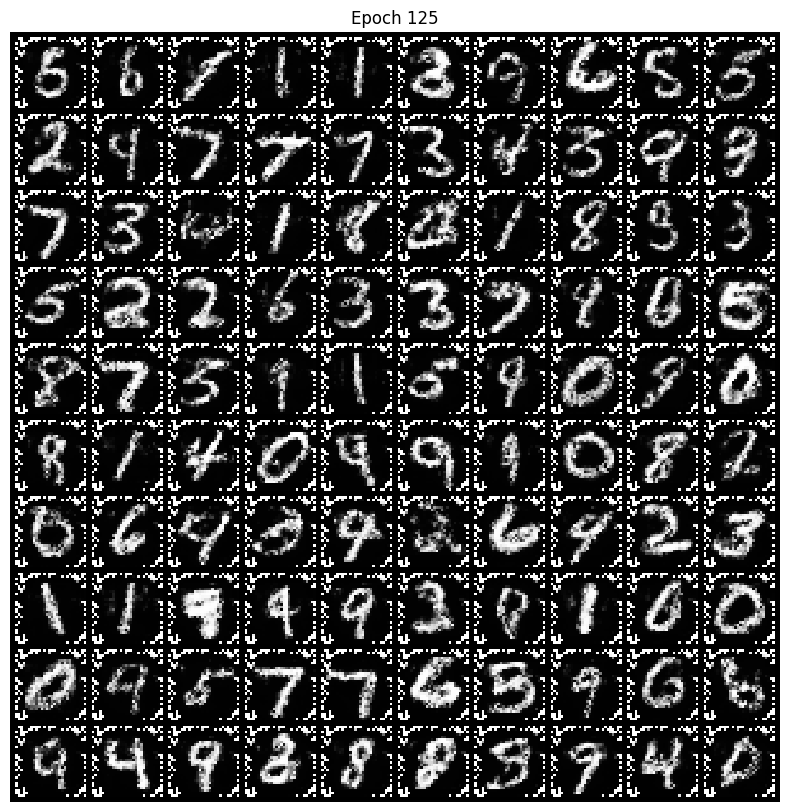

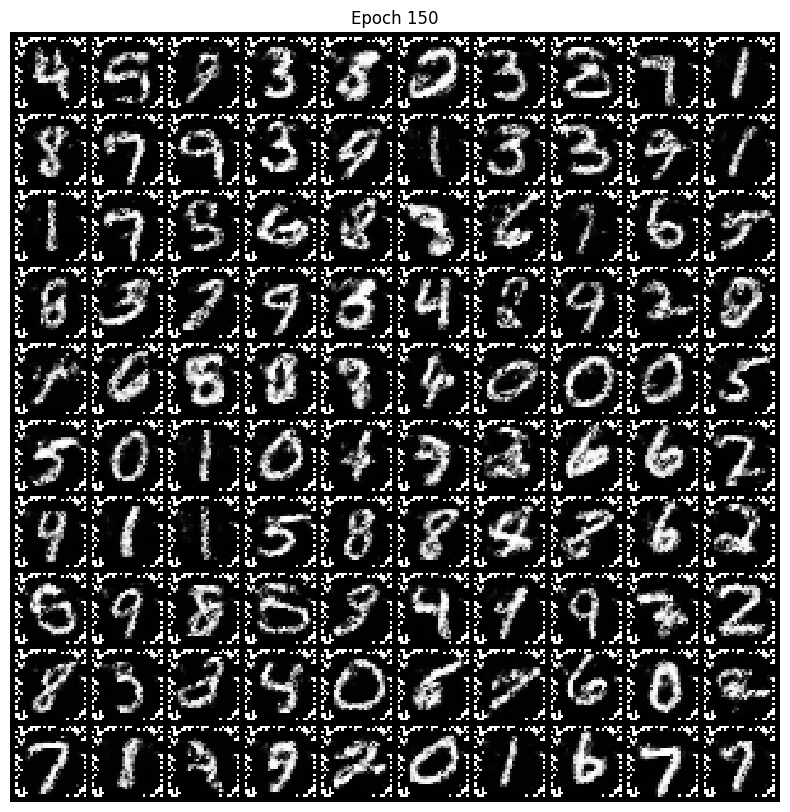

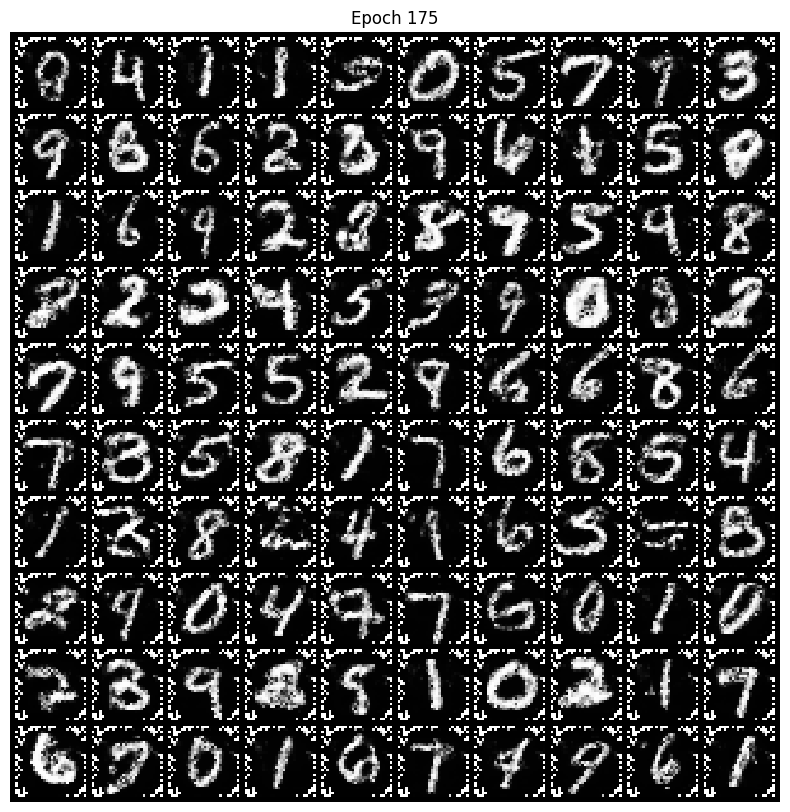

In [12]:
for i, img in enumerate(imgs):
  plt.figure(figsize=(10, 10))
  plt.axis("off")
  plt.imshow(img, interpolation='nearest')
  plt.title(f"Epoch {i*25}")